In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
from pathlib import Path
from collections.abc import Hashable
from re import M
from typing import NamedTuple, Generator, Callable
from anndata import AnnData
from itertools import product
from tqdm import tqdm

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from anndata import AnnData
from numpy.typing import NDArray
from pandas import DataFrame, Series
from scipy.stats import spearmanr, pearsonr
import torch


import spatial_transcript_inference as sti
from spatial_transcript_inference.utils import (
    subsample_adata,
    sort_df,
    filter_celltypes_by_size,
    group_by_common_obs, 
    mean_randomized_cross_feature_prediction,
    evaluate_method_by_cluster
)
from spatial_transcript_inference.nmf_utils import nmf_predictor
from spatial_transcript_inference.nn_utils import nn_predictor
from spatial_transcript_inference.tangram_utils import tangram_predictor

### Farah et al Data

In [3]:
def _adata_sp() -> AnnData:
    adata = sc.read_h5ad(
        Path.cwd() / "data" / "farah_et_al" / "inputQuery" / "sct_spatial.h5ad"
    )
    annotation = sc.read_h5ad(
        Path.cwd() / "data" / "farah_et_al" / "nico_out" / "nico_celltype_annotation.h5ad"
    ).obs["nico_ct"]
    adata.obs = adata.obs.join(annotation, how="outer")
    adata.obs["celltype"] = adata.obs["nico_ct"]
    adata = sti.utils.subsample_adata(adata, 5000, 0)
    adata.X = adata.X.toarray()
    return adata

def _adata_sc() -> AnnData:
    adata: AnnData = sc.read_h5ad(
        Path.cwd() / "data" / "farah_et_al" / "inputRef" / "sct_singleCell.h5ad"
    )
    adata.obs["celltype"] = adata.obs["major_cell_class"]
    adata = subsample_adata(adata, 5000, 0)
    adata.X = adata.X.toarray()
    return adata

### Nico example data

In [4]:
def _adata_sp() -> AnnData:
    adata_sp: AnnData = sc.read(
        Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
    ).transpose()
    obs: DataFrame = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs
    adata_sp.obs = obs
    adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
    adata_sp.obs_names_make_unique()
    #adata_sp = adata_sp[adata_sp.obs["celltype"] == celltype].copy()
    return adata_sp

def _adata_sc() -> AnnData:
    adata_sc: AnnData = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
    adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
    #adata_sc = adata_sc[adata_sc.obs["celltype"] == celltype].copy()
    adata_sc.obs_names_make_unique()
    adata_sc.X = adata_sc.X.toarray()
    return adata_sc

In [5]:
from functools import partial


adata_sp, adata_sc = _adata_sp(), _adata_sc()

# Filtering for celltypes that contain at least 20 cells
adata_sp = filter_celltypes_by_size(adata_sp, "celltype", 20)
adata_sc = filter_celltypes_by_size(adata_sc, "celltype", 20)

celltypes = np.intersect1d(adata_sc.obs["celltype"], adata_sp.obs["celltype"])

adata_sp = adata_sp[adata_sp.obs["celltype"].isin(celltypes)]
adata_sc = adata_sc[adata_sc.obs["celltype"].isin(celltypes)]

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes = list(np.intersect1d(adata_sc.var_names, adata_sp.var_names))

print(f"{len(shared_genes)=}")

len(shared_genes)=202


In [6]:
from disk_cache import disk_cache
from nn_utils import vae_predictor

# stores the respective gene imputation method under its given name
methods = {
    "nmf": disk_cache(Path("data/cache/benchmarking_refactor/nmf"))(nmf_predictor),
    "tangram": disk_cache(Path("data/cache/benchmarking_refactor/tangram"))(tangram_predictor),
    "nn": disk_cache(Path("data/cache/benchmarking_refactor/nn"))(nn_predictor),
    "vae": disk_cache(Path("data/cache/benchmarking_refactor/vae"))(vae_predictor),
}
# stores the respective query and reference matrices in a dictionary under the celltype key
counts_per_celltype = {
    celltype: tuple(map(lambda adata: np.array(adata[adata.obs["celltype"] == celltype, shared_genes].X), (adata_sp, adata_sc)))
    for celltype in celltypes
}

In [85]:
from sklearn.metrics import mean_squared_error


mean_spearman = lambda arr1, arr2: float(spearmanr(arr1.mean(axis=0), arr2.mean(axis=0))[0])
mse = lambda arr1, arr2: float(mean_squared_error(arr1, arr2))

df = evaluate_method_by_cluster(
    counts_per_celltype, 
    methods,
    mean_spearman,
    iterations=5,
    seed=0
)
df = sort_df(df, np.median, axis=0)

64it [00:01, 54.36it/s]


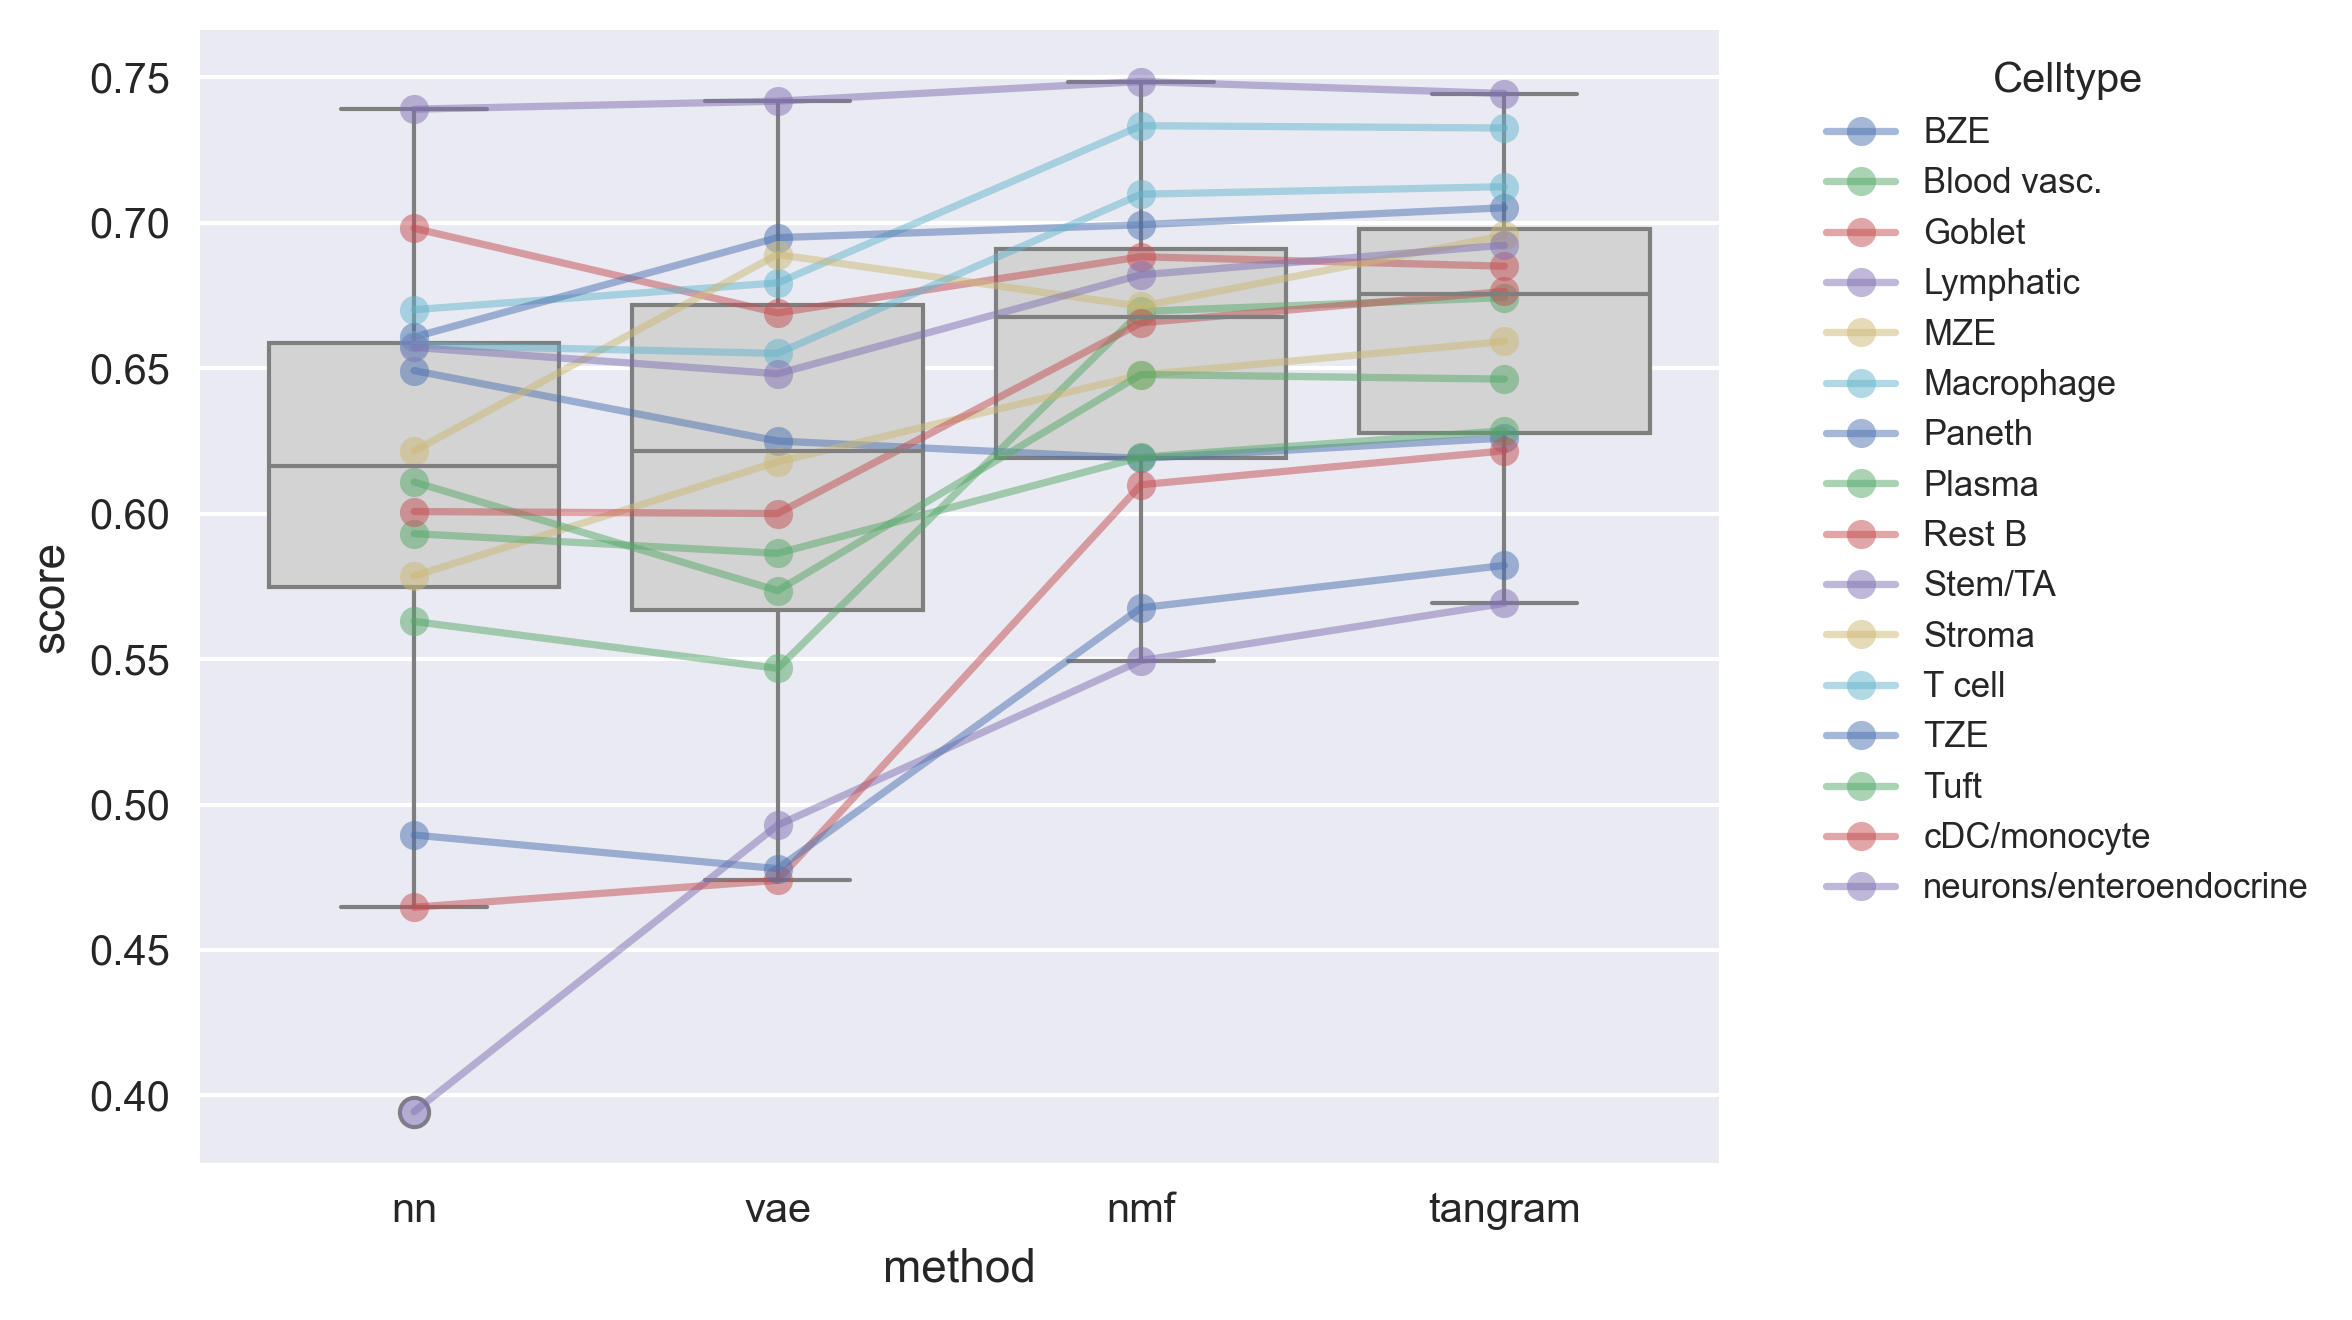

In [86]:
plt.style.use(plt.style.available[12])
df_reset = df.reset_index().melt(id_vars="celltype", var_name="method", value_name="score")
plt.figure(figsize=(8, 4.5), dpi=300)
sns.boxplot(data=df_reset, x="method", y="score", color="lightgray")
    
for celltype, group in df_reset.groupby("celltype"):
    plt.plot(group["method"], group["score"], marker="o", label=celltype, alpha=0.5)
    
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", title="Celltype")
#plt.title("Log MSE per Method with Celltype Lines")
#plt.ylim(0, 1)
plt.tight_layout()
plt.show()

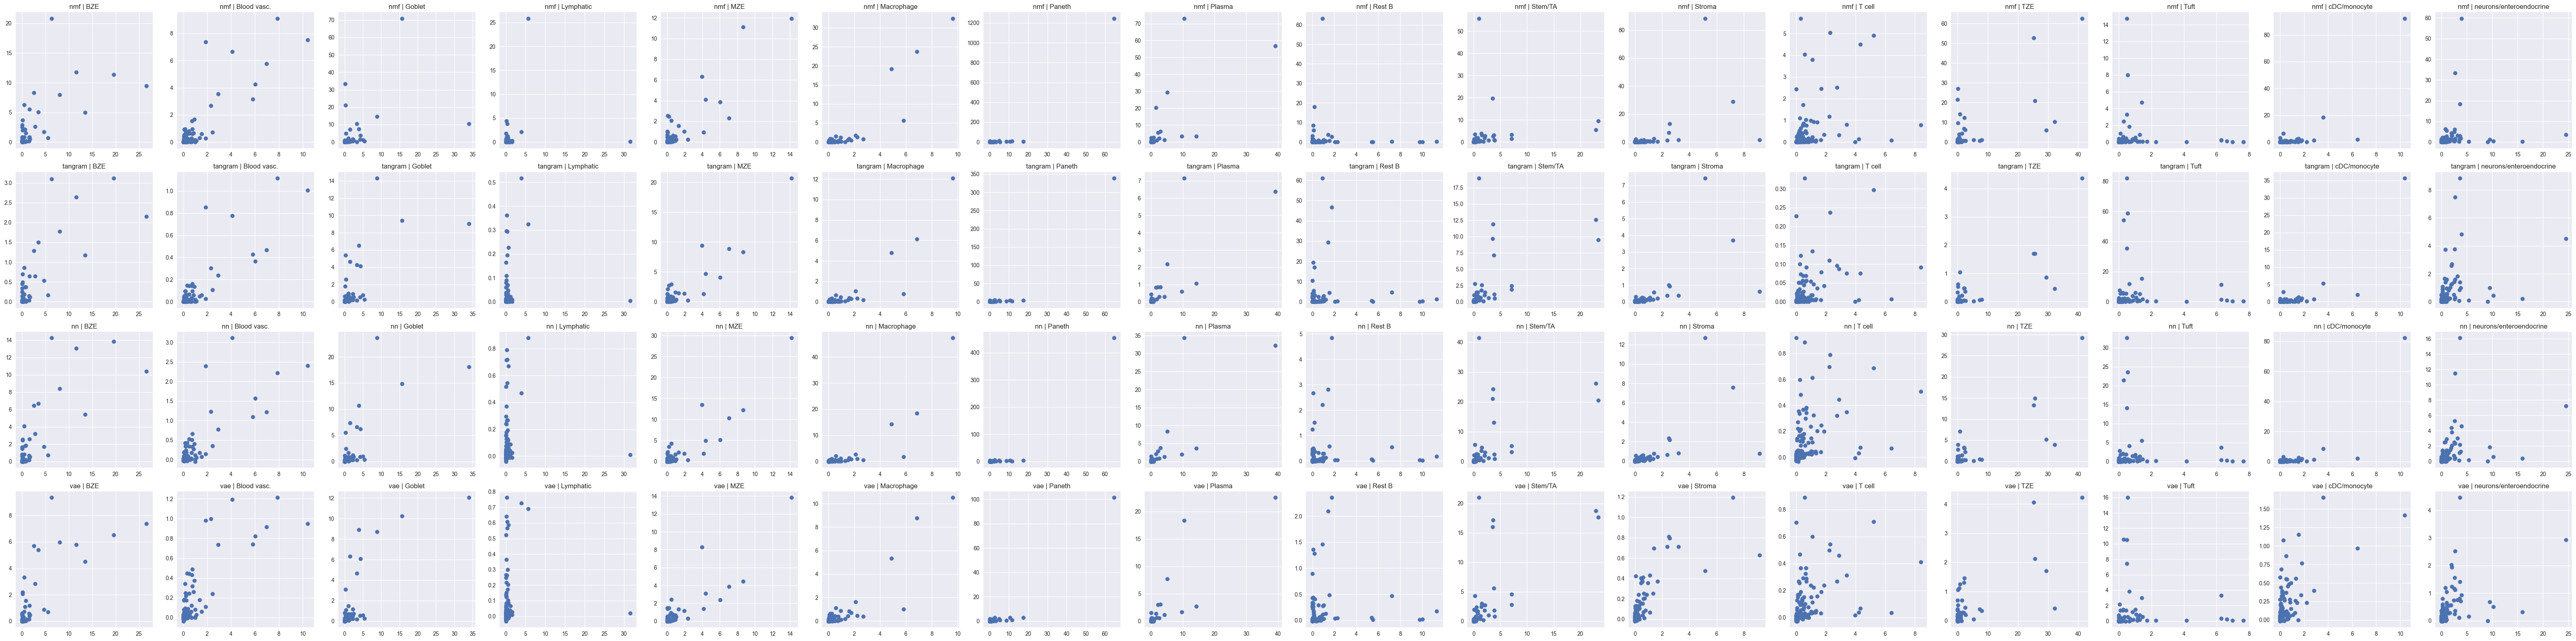

In [84]:
import itertools

nrows = len(methods)
ncols = len(counts_per_celltype)

combinations = list(itertools.product(methods.items(), counts_per_celltype.items()))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows), squeeze=False)

for idx, ((method_name, method_function), (celltype, (query, reference))) in enumerate(combinations):
    row = idx // ncols
    col = idx % ncols 
    ax = axes[row][col]

    ax.scatter(
        query.mean(axis=0),
        mean_randomized_cross_feature_prediction(query, reference, method_function, 5, 0).mean(axis=0)
    )
    ax.set_title(f'{method_name} | {celltype}')

plt.tight_layout()
plt.show()

<Axes: >

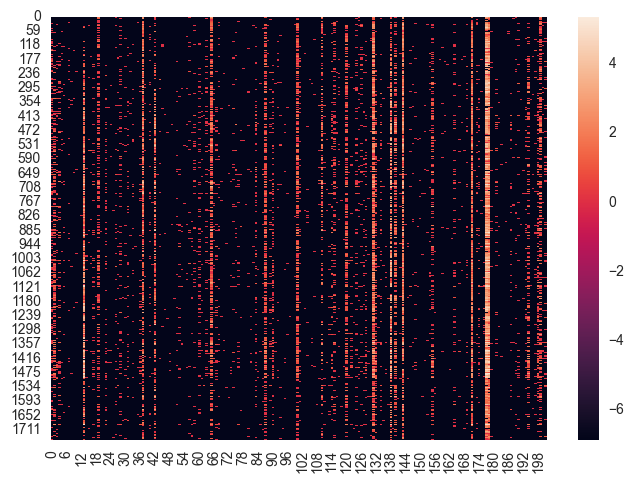

In [34]:
sns.heatmap(np.log(counts_per_celltype["BZE"][0] + 1e-3))

<Axes: >

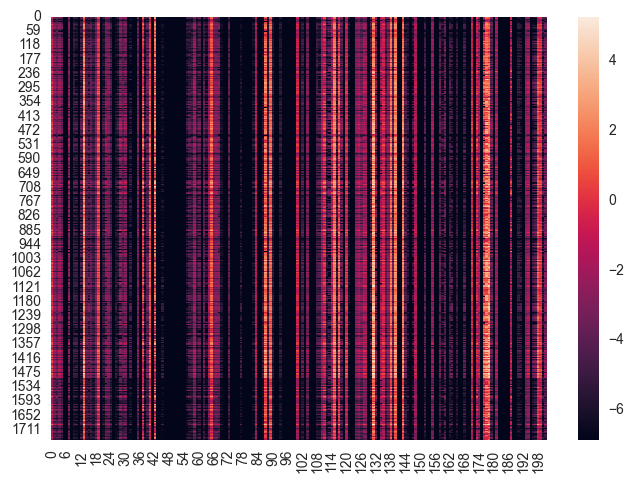

In [33]:
sns.heatmap(np.log(mean_randomized_cross_feature_prediction(*counts_per_celltype["BZE"], nmf_predictor, 5, 0)+1e-3))

convergence reached, training stopped at 150
convergence reached, training stopped at 150
convergence reached, training stopped at 140
convergence reached, training stopped at 120
convergence reached, training stopped at 140
convergence reached, training stopped at 150
convergence reached, training stopped at 80
convergence reached, training stopped at 150
convergence reached, training stopped at 140
convergence reached, training stopped at 130
convergence reached, training stopped at 90
convergence reached, training stopped at 150
convergence reached, training stopped at 150
convergence reached, training stopped at 30
convergence reached, training stopped at 140


<Axes: >

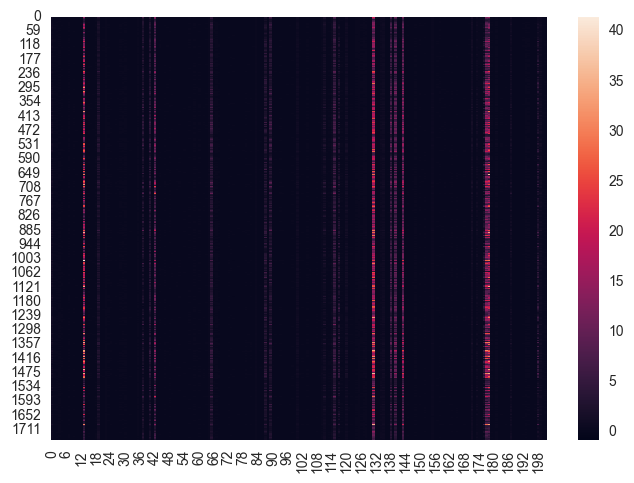

In [29]:

sns.heatmap(mean_randomized_cross_feature_prediction(*counts_per_celltype["BZE"], nn_predictor, 5))

In [26]:
mean_randomized_cross_feature_prediction(*counts_per_celltype["BZE"], nmf_predictor, 5)

array([[1.7889987e-01, 4.4597252e-03, 9.7531369e-03, ..., 1.4578640e-01,
        4.0938584e-03, 1.5313072e-03],
       [3.1139791e-01, 5.5836341e-03, 1.4673744e-02, ..., 1.6155121e-01,
        6.7958767e-03, 5.0442410e-04],
       [6.7782599e-01, 1.0497417e-02, 2.7746510e-02, ..., 2.4653058e-01,
        1.0434901e-02, 2.1494390e-03],
       ...,
       [4.1720700e-02, 2.4076314e-03, 8.1210397e-04, ..., 2.7514791e-02,
        3.5328667e-05, 3.0106939e-03],
       [1.0452845e-01, 2.7710393e-03, 4.4308566e-03, ..., 9.0266190e-02,
        1.8704046e-03, 1.4962847e-03],
       [2.6581774e-02, 2.3059095e-03, 1.5229012e-03, ..., 1.1582318e-02,
        2.7802621e-04, 6.9165725e-04]], dtype=float32)

In [ ]:
functions = [
    ("mean_query", lambda celltype: adata_sp[adata_sp.obs["celltype"] == celltype][:, shared_genes].X.mean().item()),
    ("mean_reference", lambda celltype: adata_sc[adata_sc.obs["celltype"] == celltype][:, shared_genes].X.mean().item()),
    ("n_obs_query", lambda celltype: adata_sp[adata_sp.obs["celltype"] == celltype].n_obs),
    ("n_obs_reference", lambda celltype: adata_sc[adata_sc.obs["celltype"] == celltype].n_obs),
    ("n_expressed_genes_query", lambda celltype: (adata_sp[adata_sp.obs["celltype"] == celltype, shared_genes].X.mean(axis=0) > 0).sum()),
    ("n_expressed_genes_ref", lambda celltype: (adata_sc[adata_sc.obs["celltype"] == celltype, shared_genes].X.mean(axis=0) > 0).sum()),
]
df_metrics = DataFrame(
    [{f_name: f(celltype) for f_name, f in functions} for celltype in celltypes],
    celltypes
)
df_metrics

,mean_query,mean_reference,n_obs_query,n_obs_reference,n_expressed_genes_query,n_expressed_genes_ref
BZE,0.620815,0.657014,1755,325,201,121
Blood vasc.,0.392093,0.168317,148,33,168,58
Goblet,0.623795,0.791965,453,216,189,131
Lymphatic,0.340767,0.092650,1423,267,200,98
MZE,0.323398,0.598224,95,63,101,74
Macrophage,0.304448,0.610802,351,89,188,113
Paneth,0.838302,2.795753,184,128,171,138
Plasma,0.547466,0.596971,437,85,189,103
Rest B,0.389484,0.196814,37,234,113,83
Stem/TA,0.549023,1.168517,997,420,197,140


In [ ]:
test = df.join(df_metrics)
test

,nn,vae,nmf,mean_query,mean_reference,n_obs_query,n_obs_reference,n_expressed_genes_query,n_expressed_genes_ref
celltype,,,,,,,,,
BZE,0.605677,0.613944,0.623432,0.620815,0.657014,1755,325,201,121
Blood vasc.,0.530604,0.485291,0.669711,0.392093,0.168317,148,33,168,58
Goblet,0.702200,0.671399,0.685049,0.623795,0.791965,453,216,189,131
Lymphatic,0.474409,0.432765,0.547439,0.340767,0.092650,1423,267,200,98
MZE,0.568653,0.583092,0.649019,0.323398,0.598224,95,63,101,74
Macrophage,0.677065,0.679330,0.729098,0.304448,0.610802,351,89,188,113
Paneth,0.674549,0.691177,0.703901,0.838302,2.795753,184,128,171,138
Plasma,0.541068,0.581681,0.623399,0.547466,0.596971,437,85,189,103
Rest B,0.489636,0.506440,0.598465,0.389484,0.196814,37,234,113,83


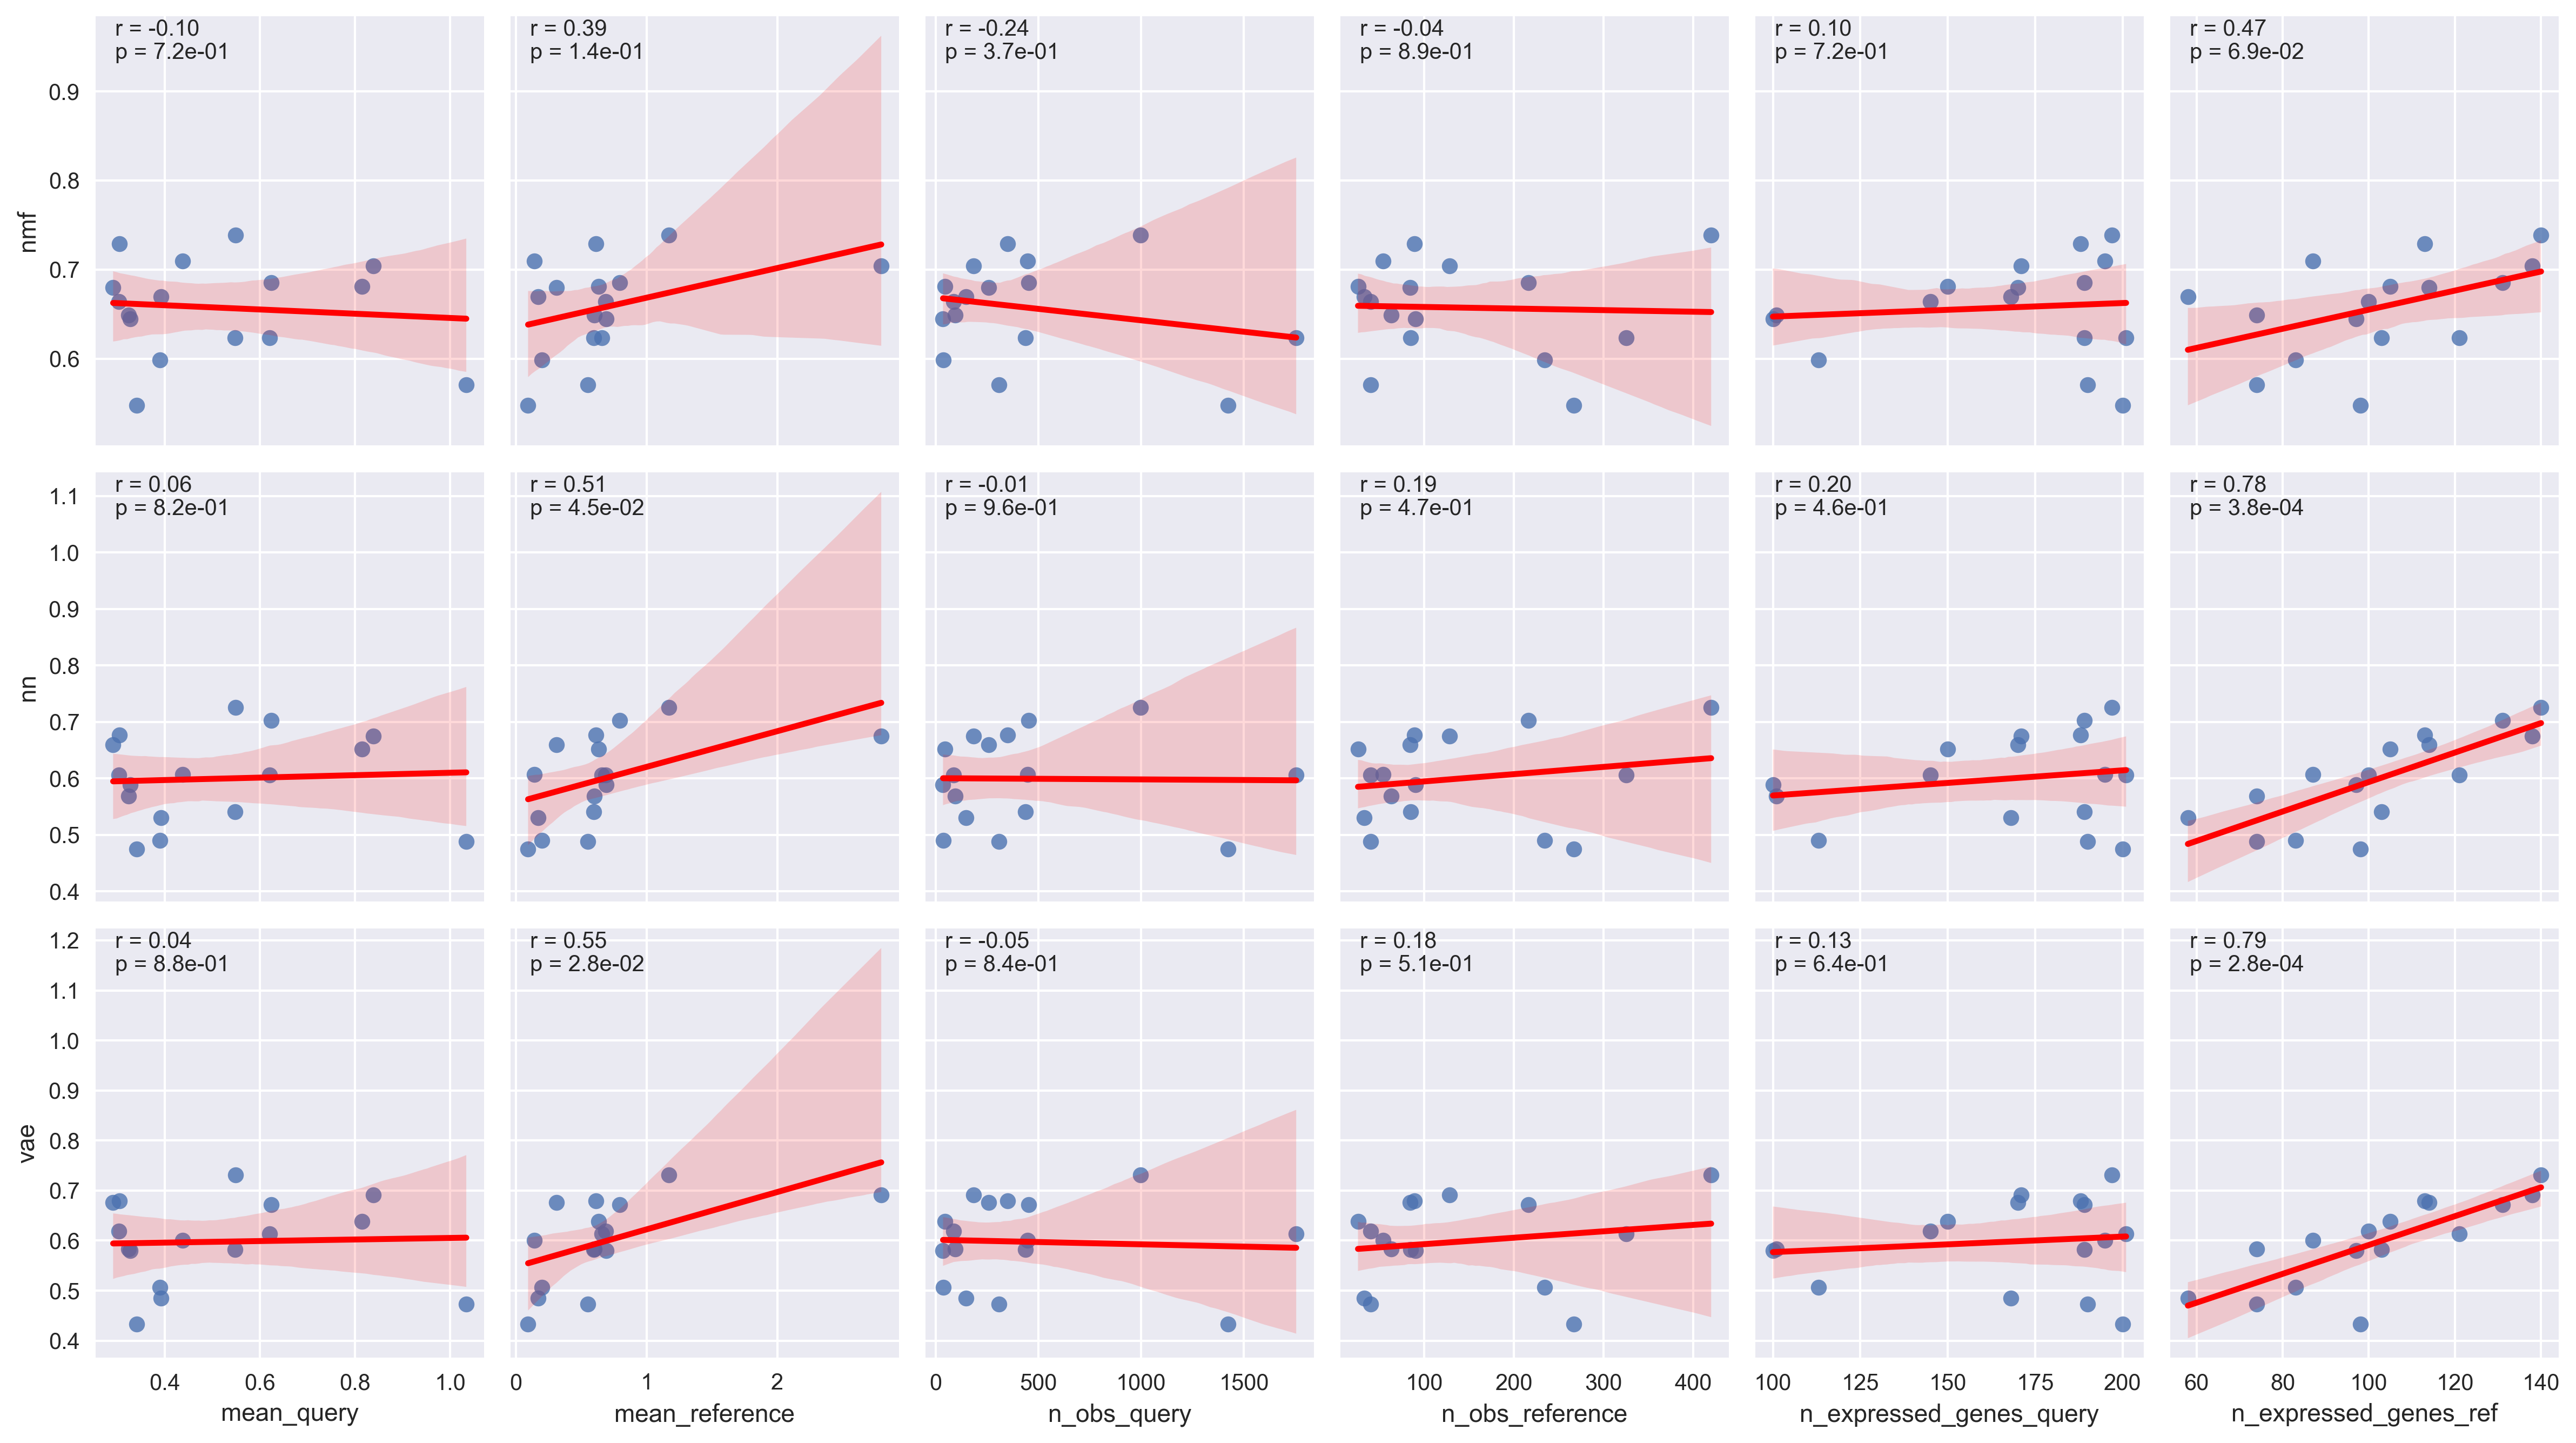

In [ ]:
def scatter_with_corr(x, y, **kwargs):
    ax = plt.gca()
    sns.regplot(x=x, y=y, ax=ax, scatter_kws={"s": 50}, line_kws={"color": "red"})
    
    r, p = pearsonr(x, y)
    ax.annotate(f'r = {r:.2f}\np = {p:.1e}', xy=(0.05, 0.9), xycoords=ax.transAxes)

g = sns.PairGrid(
    test, 
    y_vars=[method_name for method_name, _ in methods.items()], 
    x_vars=[f_name for f_name, _ in functions],
)
g.figure.set_size_inches(16, 9)
g.figure.dpi = 300 

g.map(scatter_with_corr)

plt.tight_layout()
plt.show()

In [ ]:
query_matrix, reference_matrix = map(
    lambda adata: adata[:, shared_genes].X,
    data
)

In [ ]:
from utils import mean_randomized_cross_feature_prediction, cross_feature_prediction


cross_feature_prediction(
    query_matrix,
    reference_matrix,
    nn_predictor
)

convergence reached, training stopped at 130
convergence reached, training stopped at 30
convergence reached, training stopped at 150


(7386, 202)

In [ ]:
def mean_randomized_cross_feature_prediction_adata(
    query_adata: AnnData,
    reference_adata: AnnData,
    predictor: Callable[[NDArray, NDArray], NDArray]
) -> AnnData:
    predicted_X = mean_randomized_cross_feature_prediction(
        query_adata.X,
        reference_adata.X,
        predictor, 
        10,
        seed=5
    )
    predicted_adata = query_adata.copy()
    predicted_adata.X = predicted_X
    return predicted_adata

In [ ]:
adata_sp.obs.reset_index()["celltype"]

0       Lymphatic
1       Lymphatic
2       Lymphatic
3       Lymphatic
4       Lymphatic
          ...    
7411          BZE
7412    Lymphatic
7413    Lymphatic
7414    Lymphatic
7415      Stem/TA
Name: celltype, Length: 7416, dtype: category
Categories (20, object): ['BZE', 'Blood vasc.', 'Cycling/GC B cell', 'Glial', ..., 'Tuft', 'cDC/monocyte', 'neurons/enteroendocrine', 'pDC']

In [ ]:
adata_target = adata_sp[adata_sp.obs["celltype"].isin(celltypes), shared_genes].copy()
adata_target.obs["celltype_shuffled"] = np.random.permutation(adata_target.obs["celltype"])
adata_sc.obs["celltype_shuffled"] = np.random.permutation(adata_sc.obs["celltype"])

In [ ]:
res_all = mean_randomized_cross_feature_prediction_adata(
    adata_target,
    adata_sc[adata_sc.obs["celltype"].isin(celltypes), shared_genes],
    vae_predictor
)
res_all = res_all[adata_target.obs.index]

convergence reached, training stopped at 50
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 50
convergence reached, training stopped at 50
convergence reached, training st

In [ ]:
res_celltype = sc.concat([
    mean_randomized_cross_feature_prediction_adata(
        adata_target[adata_target.obs["celltype"] == celltype],
        adata_sc[adata_sc.obs["celltype"] == celltype, shared_genes],
        vae_predictor
    )
    for celltype in celltypes
])
res_celltype = res_celltype[adata_target.obs.index]

convergence reached, training stopped at 110
convergence reached, training stopped at 110
convergence reached, training stopped at 120
convergence reached, training stopped at 120
convergence reached, training stopped at 50
convergence reached, training stopped at 100
convergence reached, training stopped at 110
convergence reached, training stopped at 80
convergence reached, training stopped at 140
convergence reached, training stopped at 70
convergence reached, training stopped at 100
convergence reached, training stopped at 140
convergence reached, training stopped at 110
convergence reached, training stopped at 80
convergence reached, training stopped at 130
convergence reached, training stopped at 130
convergence reached, training stopped at 100
convergence reached, training stopped at 60
convergence reached, training stopped at 110
convergence reached, training stopped at 90
convergence reached, training stopped at 50
convergence reached, training stopped at 100
convergence reach

In [ ]:
res_celltype_randomized = sc.concat([
    mean_randomized_cross_feature_prediction_adata(
        adata_target[adata_target.obs["celltype_shuffled"] == celltype],
        adata_sc[adata_sc.obs["celltype_shuffled"] == celltype, shared_genes],
        vae_predictor
    )
    for celltype in celltypes
])
res_celltype_randomized = res_celltype_randomized[adata_target.obs.index]

convergence reached, training stopped at 50
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 40
convergence reached, training stopped at 50
convergence reached, training stopped at 50
convergence reached, training stopped at 50
convergence reached, training st

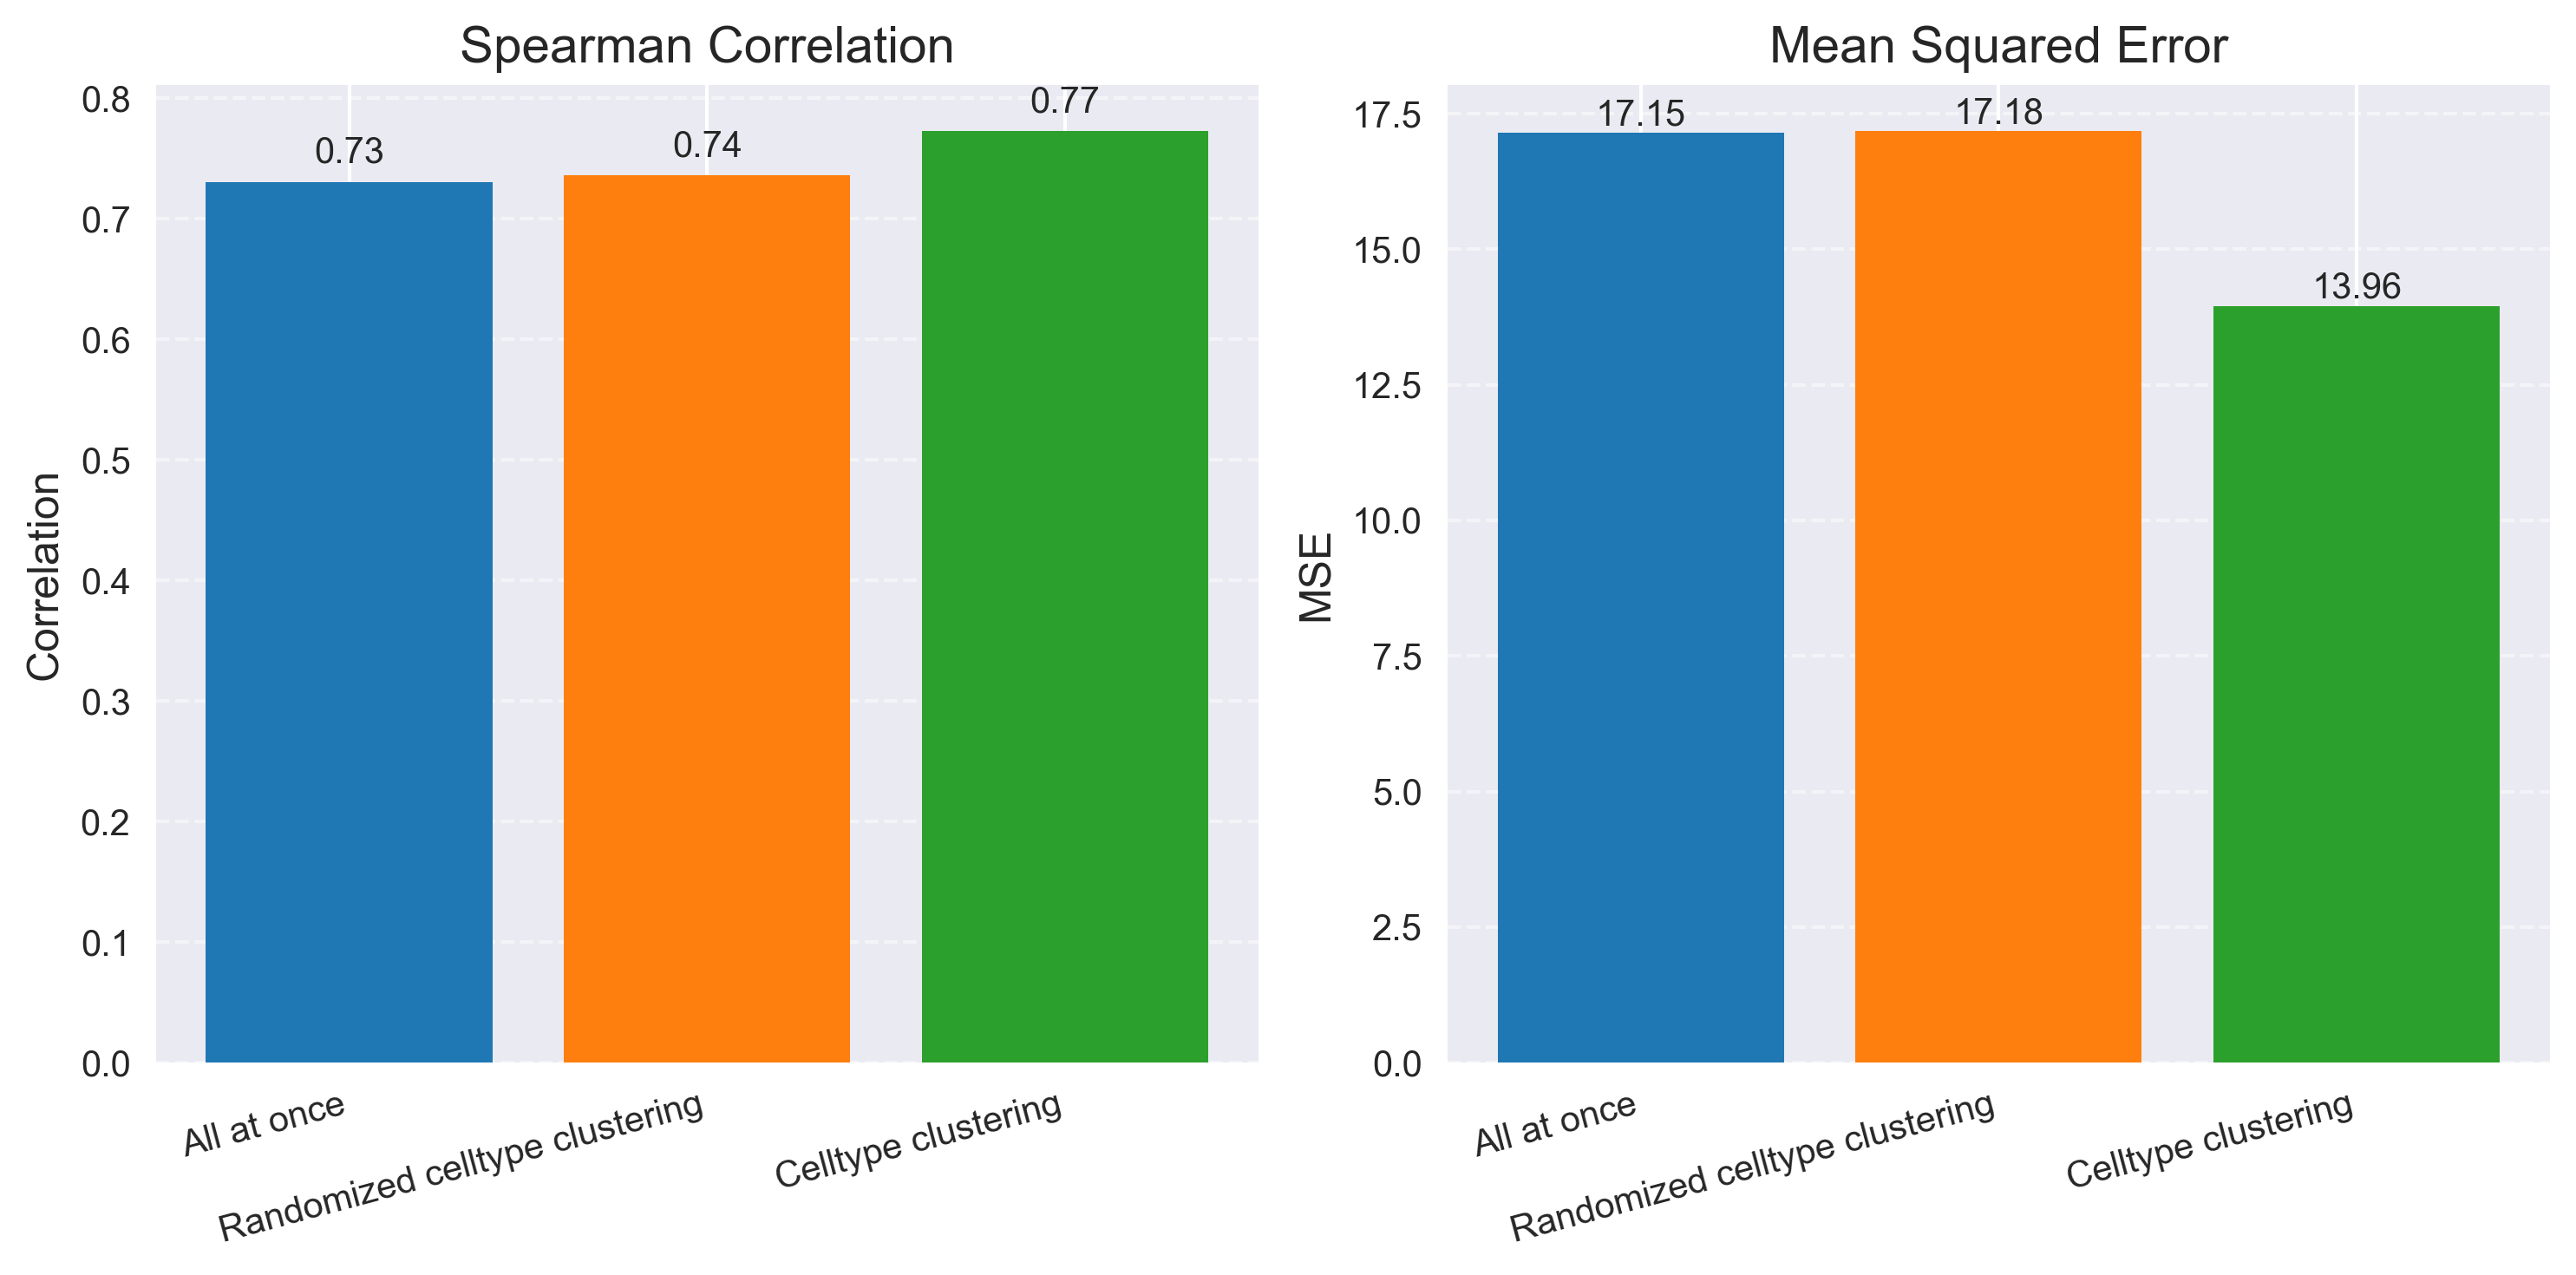

In [ ]:
from sklearn.metrics import mean_squared_error
# Compute Spearman correlations
spearman_values = list(map(
    lambda adata_pred: spearmanr(
        adata_sp[:, shared_genes].X.mean(axis=0), 
        adata_pred.X.mean(axis=0)
    )[0],
    (res_all, res_celltype_randomized, res_celltype)
))

# Compute Mean Squared Errors
mse_values = list(map(
    lambda adata_pred: mean_squared_error(
        adata_sp[adata_sp.obs["celltype"].isin(celltypes), shared_genes].X,  # ensure it's a dense matrix
        adata_pred.X
    ),
    (res_all, res_celltype_randomized, res_celltype)
))

labels = ["All at once", "Randomized celltype clustering", "Celltype clustering"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False, dpi=300)

# Left plot: Spearman
bars1 = axes[0].bar(labels, spearman_values, color=colors)
axes[0].set_title("Spearman Correlation", fontsize=14)
axes[0].set_ylabel("Correlation", fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha="center", va="bottom")

# Right plot: MSE
bars2 = axes[1].bar(labels, mse_values, color=colors)
axes[1].set_title("Mean Squared Error", fontsize=14)
axes[1].set_ylabel("MSE", fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha="center", va="bottom")

# Format
for ax in axes:
    ax.set_xticklabels(labels, rotation=15, ha="right")

plt.tight_layout()
plt.show()

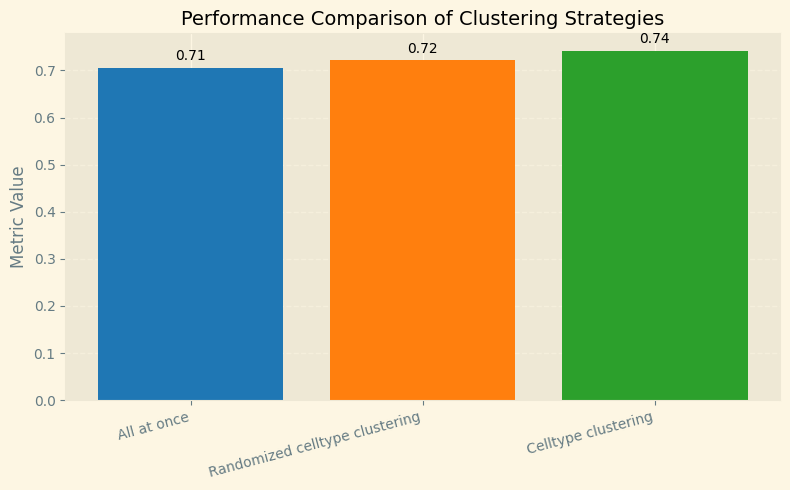

In [ ]:
import matplotlib.pyplot as plt
x = map(
    lambda adata_pred: spearmanr(adata_sp[:, shared_genes].X.mean(axis=0), adata_pred.X.mean(axis=0))[0],
    (res_all, res_celltype_randomized, res_celltype)
)

labels = ["All at once", "Randomized celltype clustering", "Celltype clustering"]
values = list(x)

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=["#1f77b4", "#ff7f0e", "#2ca02c"])

# Add value labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha="center", va="bottom")

plt.title("Performance Comparison of Clustering Strategies", fontsize=14)
plt.ylabel("Metric Value", fontsize=12)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
spearmanr(
    adata_sp[:, shared_genes].X.mean(axis=0),
    res[:, shared_genes].X.mean(axis=0),
)

SignificanceResult(statistic=np.float64(0.7429291905473897), pvalue=np.float64(1.0267325491748278e-36))

In [ ]:
from typing import Collection, Sequence, TypeVar


T = TypeVar("T")
U = TypeVar("U")
def placeholder(
    x: T,
    func1: Callable[[T], Sequence[T]],
    func2: Callable[[T], U],
    func3: Callable[[Sequence[U]], U],
) -> U:
    x = 
    pass

In [ ]:
from utils import split_into_parts


for input, output in split_into_parts(shared_genes, 3):
    input_tensor = torch.Tensor(adata_sc[:, input].X)
    target_tensor = torch.Tensor(adata_sc[:, output].X)

In [ ]:
from nn_utils import Model


def nn_predictor_parameter_optimization(
    n_latent,
    lr
) -> NDArray:
    model = Model(input_tensor, n_latent, target_tensor)
    losses = model.train(
        torch.optim.Adam,
        lr,
        torch.nn.MSELoss(),
        100000,
        convergence_cutoff=-0.01
    )
    return losses

In [ ]:
final_loss = nn_predictor_parameter_optimization(3, 0.1)[-1]
final_loss

convergence reached, training stopped at 70


17.124814987182617

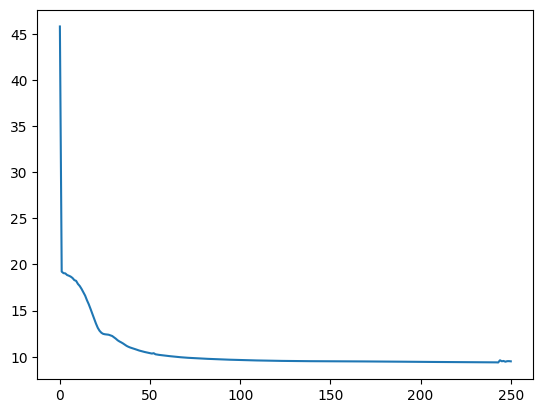

In [ ]:
plt.plot(losses)

In [ ]:
intrinsic_dimensionality_mle(adata_sc[:, shared_genes].X)

np.float64(9.681466693179077)

In [ ]:
len(losses)

321